   Age  Gender   BMI  Children Smoker     Region  Charges
0   19  Female  27.9         0    Yes  Southwest    16884
1   18    Male  33.7         1     No  Southeast     1725
2   28    Male  33.0         3     No  Southeast     4449
3   33    Male  22.7         0     No  Northwest    21984
4   32    Male  28.8         0     No  Northwest     3866

Mean Absolute Error: 7574.442963430609

Root Mean Squared Error: 10227.494115116271


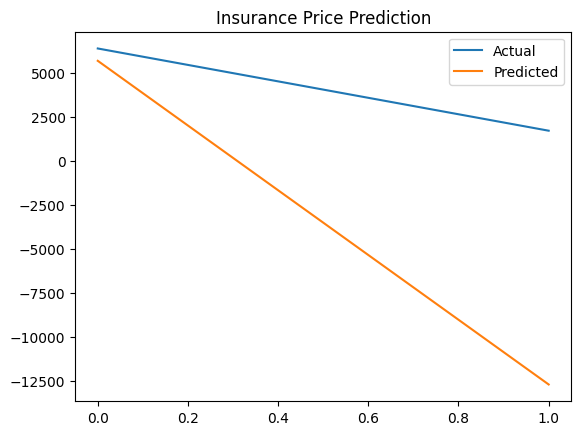


Insurance Pricing Forecast Completed Successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("insurance_data.csv")

# Show dataset
print(df.head())

# Encode categorical columns
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['Smoker'] = encoder.fit_transform(df['Smoker'])
df['Region'] = encoder.fit_transform(df['Region'])

# Features and target
X = df.drop('Charges', axis=1)

y = df['Charges']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("\nMean Absolute Error:", mae)

print("\nRoot Mean Squared Error:", rmse)

# Plot actual vs predicted
plt.plot(y_test.values, label='Actual')

plt.plot(y_pred, label='Predicted')

plt.legend()

plt.title("Insurance Price Prediction")

plt.show()

# Save model
joblib.dump(model, "insurance_model.pkl")

print("\nInsurance Pricing Forecast Completed Successfully!")